# Notebook 05 — Modeling: Anomaly Detection & Crisis Classification
## Early Warning System Krisis Pariwisata Bali — BaliGuard

Notebook ini membangun **dua model machine learning**:
1. **Isolation Forest** — anomaly detection (unsupervised), mendeteksi bulan anomali tanpa perlu label
2. **Random Forest Classifier** — klasifikasi level krisis (supervised), memprediksi AMAN/WASPADA/SIAGA/KRISIS

Dilengkapi **SHAP** untuk explainability — fitur mana yang paling berkontribusi ke prediksi krisis.

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score
)
from sklearn.pipeline import Pipeline
import joblib
import os

# SHAP
try:
    import shap
    print('SHAP tersedia')
except ImportError:
    print('SHAP belum terinstall — jalankan: pip install shap')

print('Semua library berhasil diimport')
print(f'Pandas: {pd.__version__} | Numpy: {np.__version__}')

SHAP tersedia
Semua library berhasil diimport
Pandas: 2.3.3 | Numpy: 2.2.6


## 2. Load Dataset

In [2]:
# Load master dataset
df_master = pd.read_parquet('../data/final/master_dataset_clean.parquet')
df_ext    = pd.read_csv('../data/processed/combined_additional_features_engineered_new.csv')

# ── Pastikan kolom month di master berformat string YYYY-MM ──────────────
# Period type vs string bisa menyebabkan merge gagal match
if hasattr(df_master['month'].dtype, 'freq'):        # PeriodDtype
    df_master['month'] = df_master['month'].astype(str)
else:
    df_master['month'] = pd.to_datetime(df_master['month']).dt.to_period('M').astype(str)

# ── Konversi date CSV → period YYYY-MM ───────────────────────────────────
df_ext['month'] = pd.to_datetime(df_ext['date']).dt.to_period('M').astype(str)
df_ext = df_ext.drop(columns=['date'])

# ── Pastikan tidak ada duplikasi month di CSV sebelum merge ──────────────
df_ext = df_ext.groupby('month').mean(numeric_only=True).reset_index()

# ── Merge left — master sebagai anchor (192 bulan harus tetap utuh) ──────
df = df_master.merge(df_ext, on='month', how='left')

print(df_master[
    [
        'month',
        'physical_risk_score',
        'media_risk_score',
        'tourist_perception_score',
        'external_risk_score'
    ]
].head())

print(df_master[
    [
        'physical_risk_score',
        'media_risk_score',
        'tourist_perception_score',
        'external_risk_score'
    ]
].isna().sum())

print(f"Master  : {df_master['month'].min()} → {df_master['month'].max()} ({len(df_master)} baris)")
print(f"CSV ext : {df_ext['month'].min()} → {df_ext['month'].max()} ({len(df_ext)} baris)")
print(f"Merged  : {df['month'].min()} → {df['month'].max()} ({len(df)} baris)")
print()

# ── Isi NaN external features dengan 0 (bulan yang tidak ada di CSV) ─────
ext_cols = [c for c in df_ext.columns if c != 'month' and c in df.columns]
df[ext_cols] = df[ext_cols].fillna(0)
print(f"Shape setelah merge: {df.shape}")
print(f"Null dari ext_cols  : {df[ext_cols].isnull().sum().sum()} (seharusnya 0)")


     month  physical_risk_score  media_risk_score  tourist_perception_score  \
0  2009-01             0.089349          0.075397                  0.520559   
1  2009-02             0.092702          0.097197                  0.520559   
2  2009-03             0.037040          0.321980                  0.520559   
3  2009-04             0.026324          0.195018                  0.520559   
4  2009-05             0.033700          0.039448                  0.520559   

   external_risk_score  
0             0.367944  
1             0.362267  
2             0.395440  
3             0.360803  
4             0.311416  
physical_risk_score         0
media_risk_score            0
tourist_perception_score    0
external_risk_score         0
dtype: int64
Master  : 2009-01 → 2024-12 (192 baris)
CSV ext : 2009-01 → 2025-12 (204 baris)
Merged  : 2009-01 → 2024-12 (192 baris)

Shape setelah merge: (192, 64)
Null dari ext_cols  : 0 (seharusnya 0)


In [3]:
print(df.columns.tolist())

['month', 'wisman', 'wisnus', 'usd_idr_avg', 'tpk_bintang', 'tpk_non_bintang', 'tpk_change_mom', 'tpk_ma3', 'inflasi_processed', 'indonesia_total', 'bali_share_pct', 'avg_sentiment_monthly', 'pct_negative_monthly', 'pct_positive_monthly', 'pct_neutral_monthly', 'wisman_growth_mom', 'wisman_growth_yoy', 'wisman_ma3', 'wisman_ma6', 'wisman_zscore', 'is_anomaly', 'usd_volatility_3m', 'usd_change_mom', 'month_num', 'is_peak_season', 'is_covid_period', 'bali_share_change', 'crisis_component_tourism', 'crisis_component_economy', 'crisis_component_sentiment', 'external_risk_avg_x', 'external_risk_max_x', 'external_risk_range_x', 'physical_risk_score', 'media_risk_score', 'tourist_perception_score', 'external_risk_score', 'crisis_score', 'crisis_score_100', 'crisis_level', 'wisman_lag_1', 'wisman_lag_3', 'tpk_lag_1', 'sentiment_lag_1', 'wisman_trend_3m', 'sentiment_trend_3m', 'usd_trend_3m', 'is_postcovid', 'wisman_recovery_pct', 'gdelt_crisis_score', 'economic_risk_score', 'trend_risk_score',

In [4]:
for col in [
    'physical_risk_score',
    'media_risk_score',
    'tourist_perception_score',
    'external_risk_score'
]:
    if col in df.columns:
        print(col, "-> ada")
        print(df[col].head())
    else:
        print(col, "-> TIDAK ADA")

physical_risk_score -> ada
0    0.089349
1    0.092702
2    0.037040
3    0.026324
4    0.033700
Name: physical_risk_score, dtype: float64
media_risk_score -> ada
0    0.075397
1    0.097197
2    0.321980
3    0.195018
4    0.039448
Name: media_risk_score, dtype: float64
tourist_perception_score -> ada
0    0.520559
1    0.520559
2    0.520559
3    0.520559
4    0.520559
Name: tourist_perception_score, dtype: float64
external_risk_score -> ada
0    0.367944
1    0.362267
2    0.395440
3    0.360803
4    0.311416
Name: external_risk_score, dtype: float64


### Dataset Overview

In [5]:
print('=== DATASET OVERVIEW ===')
print(f'Shape: {df.shape}')
print(f'Periode: {df["month"].min()} → {df["month"].max()}')
print()
print('Distribusi Crisis Level:')
dist = df['crisis_level'].value_counts()
for level, count in dist.items():
    pct = count/len(df)*100
    bar = '█' * int(pct/2)
    print(f'  {level:8s}: {count:3d} ({pct:.1f}%) {bar}')
print()
print('Missing values per fitur:')
nulls = df.isnull().sum()
print(nulls[nulls > 0].to_string() if nulls.any() else '  Tidak ada null')

=== DATASET OVERVIEW ===
Shape: (192, 64)
Periode: 2009-01 → 2024-12

Distribusi Crisis Level:
  WASPADA : 126 (65.6%) ████████████████████████████████
  AMAN    :  34 (17.7%) ████████
  SIAGA   :  26 (13.5%) ██████
  KRISIS  :   6 (3.1%) █

Missing values per fitur:
tpk_change_mom         1
tpk_ma3                2
wisman_ma3             2
wisman_ma6             5
wisman_zscore         11
usd_volatility_3m      2
usd_change_mom         1
bali_share_change      1
wisman_lag_1           1
wisman_lag_3           3
tpk_lag_1              1
sentiment_lag_1        1
wisman_trend_3m        2
sentiment_trend_3m     2
usd_trend_3m           2


# Mengisi NaN

In [6]:
# ── Langkah 1: Isi kolom lag/rolling yang wajar NaN di awal periode ────────
fill_zero_cols = [
    'wisman_growth_yoy',    # 12 bulan pertama NaN → isi 0 (belum ada baseline)
    'wisman_ma3',           # 2 bulan pertama NaN
    'wisman_trend_3m',      # 2 bulan pertama NaN
    'sentiment_trend_3m',   # 2 bulan pertama NaN
    'usd_volatility_3m',    # 2 bulan pertama NaN
    'bali_share_change',    # 1 bulan pertama NaN
    'wisman_growth_mom',    # 1 bulan pertama NaN
    'usd_change_mom',       # 1 bulan pertama NaN
    'tpk_change_mom',       # 1 bulan pertama NaN
]

for col in fill_zero_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# ── Langkah 2: Comprehensive imputation untuk SEMUA kolom numerik ──────────
# Tujuan: mencegah baris awal/akhir hilang karena dropna di cell berikutnya
# Strategi: ffill → bfill → median (aman untuk time series)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

nan_before = df[numeric_cols].isnull().sum().sum()
print(f"NaN sebelum imputation: {nan_before}")

# Forward fill — carry nilai terakhir yang valid ke depan
df[numeric_cols] = df[numeric_cols].ffill()
# Backward fill — isi nilai awal yang masih NaN (e.g., bulan pertama rolling)
df[numeric_cols] = df[numeric_cols].bfill()
# Median fill — jika seluruh kolom kosong (edge case)
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

nan_after = df[numeric_cols].isnull().sum().sum()
print(f"NaN setelah imputation : {nan_after}")
print(f"Periode tetap          : {df['month'].min()} → {df['month'].max()}")
print(f"Total baris            : {len(df)} (harus 192 untuk 2009-01 s.d. 2024-12)")


NaN sebelum imputation: 26
NaN setelah imputation : 0
Periode tetap          : 2009-01 → 2024-12
Total baris            : 192 (harus 192 untuk 2009-01 s.d. 2024-12)


## 3. Feature Selection & Preprocessing

In [7]:
FEATURES_CORE = [
    'wisman_growth_mom',
    'wisman_growth_yoy',
    'wisman_zscore',
    'usd_idr_avg',
    'usd_volatility_3m',
    'usd_change_mom',
    'tpk_bintang',
    'tpk_change_mom',
    'inflasi_processed',
    'bali_share_pct',
    'avg_sentiment_monthly',
    'month_num',
    'is_peak_season',
]

# DIPERBAIKI: sesuai kolom output NB04 (master_dataset_clean.parquet)
FEATURES_LAG = [
    'wisman_ma3',           # moving average 3 bulan (bukan wisman_lag_1/3)
    'wisman_trend_3m',      # slope trend wisman 3 bulan
    'bali_share_change',    # perubahan bali_share MoM
    'sentiment_trend_3m',   # slope trend sentimen 3 bulan
]

# DIPERBAIKI: sesuai kolom aktual di combined_additional_features_engineered_new.csv
FEATURES_EXTERNAL = [
    'gdelt_crisis_score',
    'economic_risk_score',
    'disaster_risk_score',
    'external_risk_avg',
    'external_risk_max',
    'external_risk_range',
    'gdelt_crisis_score_zscore',
    'disaster_risk_score_zscore',
    'physical_risk_score',
    'media_risk_score',
    'tourist_perception_score',
    'external_risk_score',
    # Opsional — uncomment jika ingin pakai semua fitur dari CSV external:
    # 'trend_risk_score',
    # 'gdelt_crisis_score_ma3',
    # 'disaster_risk_score_ma3',
    # 'economic_risk_score_ma3',
    # 'gdelt_crisis_score_slope3m',
    # 'disaster_risk_score_slope3m',
    # 'economic_risk_score_slope3m',
]

FEATURES = [f for f in FEATURES_CORE + FEATURES_LAG + FEATURES_EXTERNAL if f in df.columns]
MISSING   = [f for f in FEATURES_CORE + FEATURES_LAG + FEATURES_EXTERNAL if f not in df.columns]


print(f'Fitur tersedia    : {len(FEATURES)}')
print(f'   Core             : {len([f for f in FEATURES_CORE if f in df.columns])}')
print(f'   Lag/Trend        : {len([f for f in FEATURES_LAG if f in df.columns])}')
print(f'   External         : {len([f for f in FEATURES_EXTERNAL if f in df .columns])}')
if MISSING:
    print(f'Tidak tersedia  : {MISSING}')
    print('Jalankan NB04 FINAL untuk mendapatkan lag features')
print()

TARGET      = 'crisis_level'
LABEL_ORDER = ['AMAN', 'WASPADA', 'SIAGA', 'KRISIS']


Fitur tersedia    : 26
   Core             : 13
   Lag/Trend        : 4
   External         : 9
Tidak tersedia  : ['external_risk_avg', 'external_risk_max', 'external_risk_range']
Jalankan NB04 FINAL untuk mendapatkan lag features



In [8]:
# 1. Simpan semua baris — NaN sudah diimputasi di cell sebelumnya
#    Hanya drop baris yang TARGET-nya NaN (tidak bisa diimputasi secara bermakna)
df_model = df.dropna(subset=[TARGET]).copy().reset_index(drop=True)

# 2. Encode crisis level ke integer (AMAN=0, WASPADA=1, SIAGA=2, KRISIS=3)
label_map = {label: i for i, label in enumerate(LABEL_ORDER)}
df_model['crisis_label_enc'] = df_model[TARGET].map(label_map)

# 3. Verifikasi
print('=== df_model SIAP ===')
print(f'Shape       : {df_model.shape}')
print(f'Periode     : {df_model["month"].min()} → {df_model["month"].max()}')
print(f'Fitur aktif : {len(FEATURES)}')
print()
print('Distribusi crisis_label_enc:')
for label, idx in label_map.items():
    count = (df_model['crisis_label_enc'] == idx).sum()
    print(f'  {idx} ({label:8s}): {count} baris')
print()

# Pastikan crisis_score_100 ada (dipakai visualisasi nanti)
if 'crisis_score_100' not in df_model.columns:
    print("'crisis_score_100' tidak ditemukan — cek output NB04")
else:
    print("crisis_score_100 tersedia")

=== df_model SIAP ===
Shape       : (192, 65)
Periode     : 2009-01 → 2024-12
Fitur aktif : 26

Distribusi crisis_label_enc:
  0 (AMAN    ): 34 baris
  1 (WASPADA ): 126 baris
  2 (SIAGA   ): 26 baris
  3 (KRISIS  ): 6 baris

crisis_score_100 tersedia


In [9]:
# Mencegah recovery COVID mendominasi model secara tidak proporsional
df_model[FEATURES] = df_model[FEATURES].clip(
    lower=df_model[FEATURES].quantile(0.01),
    upper=df_model[FEATURES].quantile(0.99),
    axis=1
)

print('Setelah clip 1%-99%:')
print(f'wisman_growth_mom max: {df_model["wisman_growth_mom"].max():.3f}')
print(f'wisman_growth_yoy max: {df_model["wisman_growth_yoy"].max():.3f}')

Setelah clip 1%-99%:
wisman_growth_mom max: 7.171
wisman_growth_yoy max: 114376.430


## 4. Normalisasi Fitur

In [10]:
print('=== CEK INFINITY & NULL ===')
for f in FEATURES:
    inf_count = np.isinf(df_model[f]).sum()
    nan_count = np.isnan(df_model[f]).sum()
    if inf_count > 0 or nan_count > 0:
        print(f'  {f}: {inf_count} inf, {nan_count} nan')

# Ganti inf dengan NaN dulu, lalu isi dengan median kolom
df_model[FEATURES] = df_model[FEATURES].replace([np.inf, -np.inf], np.nan)
df_model[FEATURES] = df_model[FEATURES].fillna(df_model[FEATURES].median())

# Verifikasi sudah bersih
inf_total = np.isinf(df_model[FEATURES].values).sum()
nan_total = np.isnan(df_model[FEATURES].values).sum()
print(f'Setelah fix — inf: {inf_total}, nan: {nan_total}')
print()

# Standardisasi fitur
scaler = StandardScaler()
X = df_model[FEATURES].values
X_scaled = scaler.fit_transform(X)
y = df_model['crisis_label_enc'].values
months = df_model['month'].values

print('Shape X (fitur):', X_scaled.shape)
print('Shape y (target):', y.shape)
print()
print('Statistik fitur setelah scaling (mean ≈ 0, std ≈ 1):')
scaled_df = pd.DataFrame(X_scaled, columns=FEATURES)
print(scaled_df.describe().round(2).to_string())

=== CEK INFINITY & NULL ===
Setelah fix — inf: 0, nan: 0

Shape X (fitur): (192, 26)
Shape y (target): (192,)

Statistik fitur setelah scaling (mean ≈ 0, std ≈ 1):
       wisman_growth_mom  wisman_growth_yoy  wisman_zscore  usd_idr_avg  usd_volatility_3m  usd_change_mom  tpk_bintang  tpk_change_mom  inflasi_processed  bali_share_pct  avg_sentiment_monthly  month_num  is_peak_season  wisman_ma3  wisman_trend_3m  bali_share_change  sentiment_trend_3m  gdelt_crisis_score  economic_risk_score  disaster_risk_score  gdelt_crisis_score_zscore  disaster_risk_score_zscore  physical_risk_score  media_risk_score  tourist_perception_score  external_risk_score
count             192.00             192.00         192.00       192.00             192.00          192.00       192.00          192.00             192.00          192.00                 192.00     192.00          192.00      192.00           192.00             192.00              192.00              192.00               192.00               

## 5. Model 1 — Isolation Forest (Anomaly Detection)

**Isolation Forest** mendeteksi anomali secara *unsupervised* — tanpa membutuhkan label.
Prinsipnya: data anomali lebih mudah "diisolasi" dalam pohon keputusan karena berbeda dari mayoritas data.

In [11]:
# Train Isolation Forest
# contamination = perkiraan % anomali dalam data (~20% COVID + krisis lain)
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.15,   # estimasi 15% data adalah anomali
    random_state=42,
    n_jobs=-1
)

iso_forest.fit(X_scaled)

# Prediksi: -1 = anomali, 1 = normal
iso_pred = iso_forest.predict(X_scaled)
iso_scores = iso_forest.score_samples(X_scaled)  # skor anomali (lebih negatif = lebih anomali)

# Tambahkan hasil ke dataframe
df_model['iso_prediction'] = iso_pred
df_model['iso_anomaly'] = (iso_pred == -1).astype(int)
df_model['iso_score'] = iso_scores

# Konversi ke label
df_model['iso_label'] = df_model['iso_anomaly'].map({1: 'ANOMALI', 0: 'NORMAL'})

print('=== HASIL ISOLATION FOREST ===')
print(f'Total anomali terdeteksi: {df_model["iso_anomaly"].sum()} bulan')
print(f'Persentase: {df_model["iso_anomaly"].mean()*100:.1f}%')
print()
print('Bulan anomali yang terdeteksi:')
anomali = df_model[df_model['iso_anomaly']==1][['month','iso_score',TARGET,'crisis_score_100']]
print(anomali.sort_values('iso_score').to_string())

=== HASIL ISOLATION FOREST ===
Total anomali terdeteksi: 29 bulan
Persentase: 15.1%

Bulan anomali yang terdeteksi:
       month  iso_score crisis_level  crisis_score_100
135  2020-04  -0.617159       KRISIS         77.013790
134  2020-03  -0.605986       KRISIS         75.327390
136  2020-05  -0.574405       KRISIS         67.336559
133  2020-02  -0.568929        SIAGA         59.513970
137  2020-06  -0.555946        SIAGA         52.871249
144  2021-01  -0.549554        SIAGA         49.850974
141  2020-10  -0.542579        SIAGA         27.601691
143  2020-12  -0.540927        SIAGA         32.576855
71   2014-12  -0.532387      WASPADA         37.614516
138  2020-07  -0.530812       KRISIS         71.491934
168  2023-01  -0.530563      WASPADA         39.257469
139  2020-08  -0.529957       KRISIS         63.400143
11   2009-12  -0.516572      WASPADA         35.065480
132  2020-01  -0.515551      WASPADA         37.142083
10   2009-11  -0.514448      WASPADA         37.801883
140 

### 5.1 Validasi — Overlap dengan Periode COVID

In [12]:
# Berapa % anomali IF yang overlap dengan periode COVID?
covid_months = df_model[df_model['month'].between('2020-01','2021-12')]
iso_covid = covid_months['iso_anomaly'].sum()
total_covid = len(covid_months)

print(f'Periode COVID (2020–2021): {total_covid} bulan')
print(f'Terdeteksi sebagai anomali IF: {iso_covid} bulan ({iso_covid/total_covid*100:.1f}%)')
print()

# Confusion: anomali vs non-anomali vs crisis_level
cross = pd.crosstab(df_model[TARGET], df_model['iso_label'])
print('Crosstab Crisis Level vs Isolation Forest:')
print(cross.to_string())
print()

# Precision: dari anomali IF, berapa yang memang SIAGA/KRISIS?
iso_anomali_rows = df_model[df_model['iso_anomaly']==1]
correct = iso_anomali_rows[TARGET].isin(['SIAGA','KRISIS']).sum()
precision = correct / len(iso_anomali_rows) * 100
print(f'Precision IF (anomali = SIAGA/KRISIS): {precision:.1f}%')

Periode COVID (2020–2021): 24 bulan
Terdeteksi sebagai anomali IF: 16 bulan (66.7%)

Crosstab Crisis Level vs Isolation Forest:
iso_label     ANOMALI  NORMAL
crisis_level                 
AMAN                1      33
KRISIS              6       0
SIAGA              12      14
WASPADA            10     116

Precision IF (anomali = SIAGA/KRISIS): 62.1%


### 5.2 Visualisasi Anomaly Score

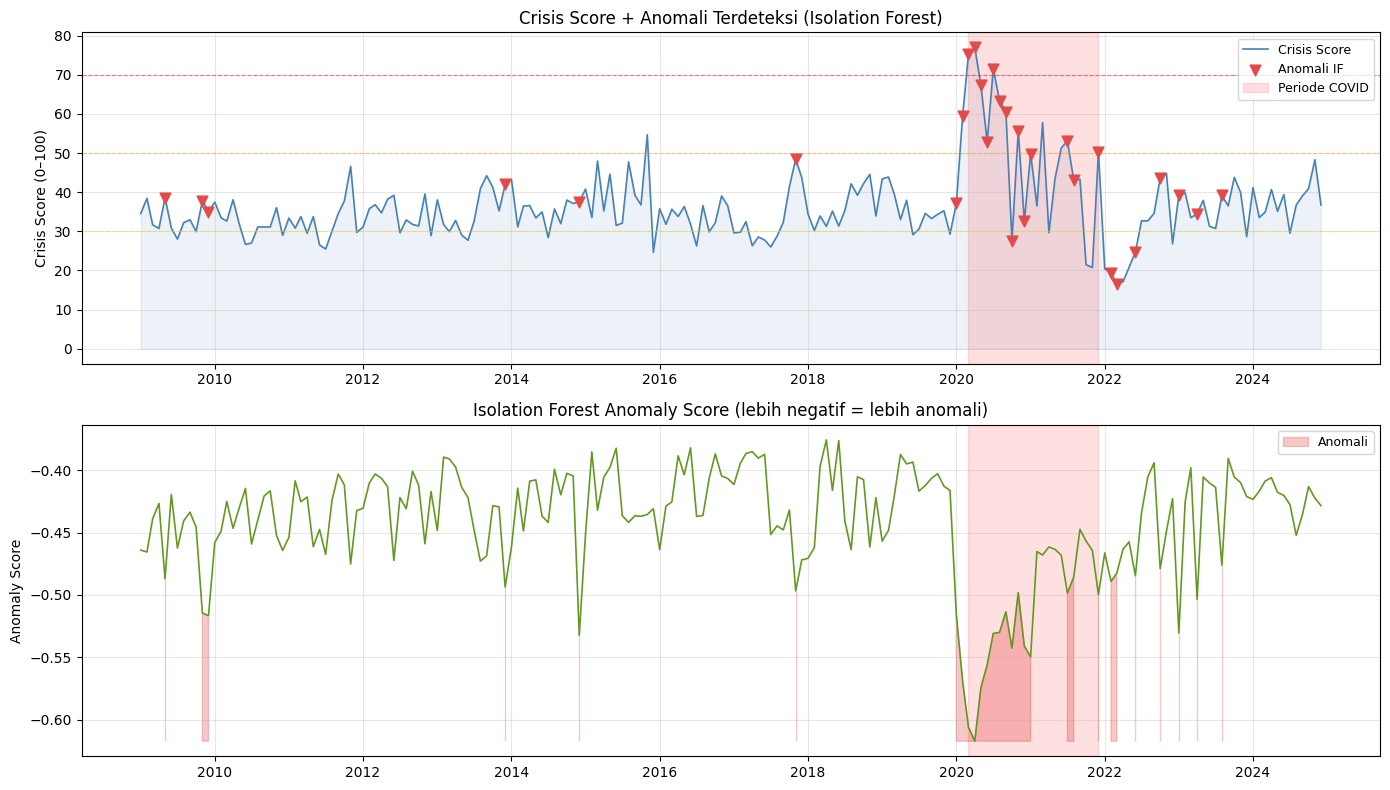

Plot disimpan ke ../data/final/isolation_forest_results.png


In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: Crisis score + anomali markers
ax1 = axes[0]
months_dt = pd.to_datetime(df_model['month'].astype(str))
ax1.plot(months_dt, df_model['crisis_score_100'], color='steelblue', linewidth=1.2, label='Crisis Score')
ax1.fill_between(months_dt, 0, df_model['crisis_score_100'], alpha=0.1, color='steelblue')

# Anomali markers
anomali_mask = df_model['iso_anomaly'] == 1
ax1.scatter(months_dt[anomali_mask], df_model['crisis_score_100'][anomali_mask],
            color='#E24B4A', s=60, zorder=5, label='Anomali IF', marker='v')

# COVID shading
covid_start = pd.to_datetime('2020-03-01')
covid_end = pd.to_datetime('2021-12-01')
ax1.axvspan(covid_start, covid_end, alpha=0.12, color='red', label='Periode COVID')
ax1.axhline(70, color='red', linestyle='--', alpha=0.5, linewidth=0.8)
ax1.axhline(50, color='orange', linestyle='--', alpha=0.5, linewidth=0.8)
ax1.axhline(30, color='gold', linestyle='--', alpha=0.5, linewidth=0.8)
ax1.set_title('Crisis Score + Anomali Terdeteksi (Isolation Forest)', fontsize=12)
ax1.set_ylabel('Crisis Score (0–100)')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# Plot 2: Anomaly score timeline
ax2 = axes[1]
ax2.plot(months_dt, df_model['iso_score'], color='#639922', linewidth=1.2)
ax2.fill_between(months_dt, df_model['iso_score'].min(), df_model['iso_score'],
                 where=df_model['iso_anomaly']==1, alpha=0.3, color='#E24B4A', label='Anomali')
ax2.axvspan(covid_start, covid_end, alpha=0.12, color='red')
ax2.set_title('Isolation Forest Anomaly Score (lebih negatif = lebih anomali)', fontsize=12)
ax2.set_ylabel('Anomaly Score')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
os.makedirs('../data/final', exist_ok=True)
plt.savefig('../data/final/isolation_forest_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot disimpan ke ../data/final/isolation_forest_results.png")

## 6. Model 2 — Random Forest Classifier (Crisis Level Prediction)

**Random Forest** memprediksi level krisis (AMAN/WASPADA/SIAGA/KRISIS) berdasarkan semua fitur.
Menggunakan **TimeSeriesSplit** untuk evaluasi — tidak boleh random split pada data time series.

In [14]:
# ════════════════════════════════════════════════════════════════
# SOLUSI: Custom Walk-Forward CV yang COVID-aware
# ════════════════════════════════════════════════════════════════
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, f1_score 
import numpy as np

# ── Strategi 1: min_train_size agar setiap fold punya konteks cukup ──
# Pastikan training set minimal 60% data (≥107 baris) sebelum test dimulai
n_total     = len(X_scaled)
min_train   = int(n_total * 0.60)   # 107 baris ≈ sampai ~2018
test_size   = int(n_total * 0.10)   # ~18 baris per fold ≈ 1.5 tahun
gap         = 1                      # 1 bulan gap — cegah leakage seasonal

print('=== CUSTOM WALK-FORWARD CV (COVID-aware) ===')
print(f'Total data   : {n_total} baris')
print(f'Min training : {min_train} baris (dari awal)')
print(f'Test size    : {test_size} baris per fold')
print(f'Gap          : {gap} bulan')
print()

# Buat manual fold indices
fold_results = []
fold_num = 1

train_end = min_train
while train_end + gap + test_size <= n_total:
    test_start = train_end + gap
    test_end   = test_start + test_size

    train_idx = np.arange(0, train_end)
    test_idx  = np.arange(test_start, test_end)

    # Distribusi kelas di tiap fold
    train_labels = [LABEL_ORDER[i] for i in y[train_idx]]
    test_labels  = [LABEL_ORDER[i] for i in y[test_idx]]

    # Cek apakah semua kelas tersedia di training
    train_classes = set(y[train_idx])
    test_classes  = set(y[test_idx])
    coverage      = test_classes.issubset(train_classes)

    # Fit & evaluate
    rf_cv = RandomForestClassifier(
        n_estimators=300, max_depth=8,
        min_samples_split=5, min_samples_leaf=3,
        class_weight='balanced', random_state=42, n_jobs=-1
    )
    rf_cv.fit(X_scaled[train_idx], y[train_idx])
    y_fold_pred = rf_cv.predict(X_scaled[test_idx])

    acc = accuracy_score(y[test_idx], y_fold_pred)
    f1  = f1_score(y[test_idx], y_fold_pred, average='macro', zero_division=0)

    # Label periode
    period_start = str(months[test_start])[:7]
    period_end   = str(months[test_end - 1])[:7]

    fold_results.append({
        'fold': fold_num,
        'train_n': len(train_idx),
        'test_n': len(test_idx),
        'period': f'{period_start} -> {period_end}',
        'coverage': '✓' if coverage else '⚠ partial',
        'accuracy': acc,
        'f1_macro': f1
    })

    print(f'Fold {fold_num}: train[0–{train_end}] test[{test_start}–{test_end}]')
    print(f'  Periode  : {period_start} -> {period_end}')
    print(f'  Kelas OK : {"semua kelas tercover" if coverage else "test punya kelas baru!"}')
    print(f'  Accuracy : {acc:.3f}   F1 Macro: {f1:.3f}')
    print()

    train_end += test_size
    fold_num  += 1

# Ringkasan
accs = [r['accuracy'] for r in fold_results]
f1s  = [r['f1_macro'] for r in fold_results]
print('═' * 55)
print(f'Mean Accuracy : {np.mean(accs):.3f} ± {np.std(accs):.3f}')
print(f'Mean F1 Macro : {np.mean(f1s):.3f} ± {np.std(f1s):.3f}')
print(f'Jumlah fold   : {len(fold_results)}')

# ── Simpan hasil sebagai numpy array (dipakai Cell ringkasan) ──
cv_scores = np.array(accs)
cv_f1     = np.array(f1s)

print()
print('═' * 55)
print(f'Walk-Forward CV Summary ({len(fold_results)} fold):')
print(f'  Mean Accuracy  : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')
print(f'  Mean F1 Macro  : {cv_f1.mean():.3f} ± {cv_f1.std():.3f}')
print()
print('Detail per fold:')
for r in fold_results:
    print(f"  Fold {r['fold']}: {r['period']} | Acc={r['accuracy']:.3f} | F1={r['f1_macro']:.3f} | {r['coverage']}")


=== CUSTOM WALK-FORWARD CV (COVID-aware) ===
Total data   : 192 baris
Min training : 115 baris (dari awal)
Test size    : 19 baris per fold
Gap          : 1 bulan

Fold 1: train[0–115] test[116–135]
  Periode  : 2018-09 -> 2020-03
  Kelas OK : test punya kelas baru!
  Accuracy : 0.789   F1 Macro: 0.351

Fold 2: train[0–134] test[135–154]
  Periode  : 2020-04 -> 2021-10
  Kelas OK : test punya kelas baru!
  Accuracy : 0.000   F1 Macro: 0.000

Fold 3: train[0–153] test[154–173]
  Periode  : 2021-11 -> 2023-05
  Kelas OK : semua kelas tercover
  Accuracy : 0.684   F1 Macro: 0.506

Fold 4: train[0–172] test[173–192]
  Periode  : 2023-06 -> 2024-12
  Kelas OK : semua kelas tercover
  Accuracy : 0.789   F1 Macro: 0.425

═══════════════════════════════════════════════════════
Mean Accuracy : 0.566 ± 0.329
Mean F1 Macro : 0.321 ± 0.193
Jumlah fold   : 4

═══════════════════════════════════════════════════════
Walk-Forward CV Summary (4 fold):
  Mean Accuracy  : 0.566 ± 0.329
  Mean F1 Macro  :

### 6.1 Confusion Matrix

In [15]:
from sklearn.preprocessing import LabelEncoder

# Definisi ulang le & label_order — konsisten dengan LABEL_ORDER
le = LabelEncoder()
le.classes_ = np.array(LABEL_ORDER)   # fit manual, urutan sudah benar

# Alias lowercase untuk kompatibilitas cell-cell lama di notebook
label_order = LABEL_ORDER             # ['AMAN', 'WASPADA', 'SIAGA', 'KRISIS']

# Verifikasi
print('LabelEncoder classes :', le.classes_)
print('label_order          :', label_order)
print()
print('Test inverse_transform:', le.inverse_transform([0, 1, 2, 3]))

# ── Train FINAL RF model pada semua data (setelah CV selesai evaluasi) ──
rf_model = RandomForestClassifier(
    n_estimators=300, max_depth=8,
    min_samples_split=5, min_samples_leaf=3,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_model.fit(X_scaled, y)

# Prediksi pada semua data (in-sample) untuk evaluasi & penyimpanan
y_pred        = rf_model.predict(X_scaled)
y_pred_labels = le.inverse_transform(y_pred)

print()
print('=== FINAL RF MODEL — dilatih pada semua data ===')
print(f'Sampel training : {len(X_scaled)}')
print(f'Training Accuracy: {accuracy_score(y, y_pred)*100:.1f}%')
print()
print(classification_report(le.inverse_transform(y), y_pred_labels, zero_division=0))


LabelEncoder classes : ['AMAN' 'WASPADA' 'SIAGA' 'KRISIS']
label_order          : ['AMAN', 'WASPADA', 'SIAGA', 'KRISIS']

Test inverse_transform: ['AMAN' 'WASPADA' 'SIAGA' 'KRISIS']

=== FINAL RF MODEL — dilatih pada semua data ===
Sampel training : 192
Training Accuracy: 99.5%

              precision    recall  f1-score   support

        AMAN       0.97      1.00      0.99        34
      KRISIS       1.00      1.00      1.00         6
       SIAGA       1.00      1.00      1.00        26
     WASPADA       1.00      0.99      1.00       126

    accuracy                           0.99       192
   macro avg       0.99      1.00      1.00       192
weighted avg       0.99      0.99      0.99       192



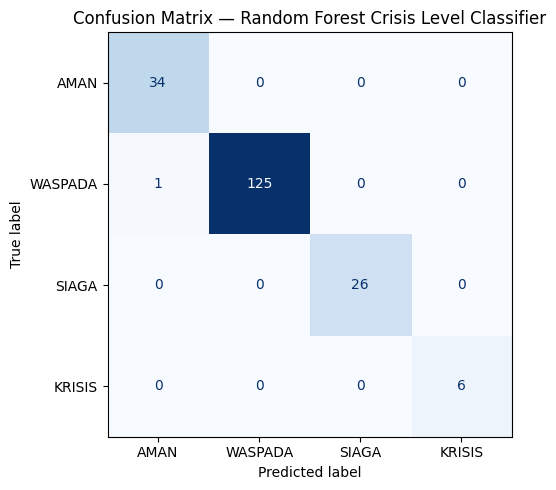

Confusion matrix disimpan


In [16]:
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(le.inverse_transform(y), y_pred_labels, labels=label_order)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_order)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Random Forest Crisis Level Classifier', fontsize=12)
plt.tight_layout()
plt.savefig('../data/final/confusion_matrix_rf.png', dpi=150, bbox_inches='tight')
plt.show()
print('Confusion matrix disimpan')

## 6b. Baseline Model Comparison

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree        import DecisionTreeClassifier
from sklearn.dummy       import DummyClassifier
from sklearn.metrics     import f1_score, roc_auc_score, classification_report
import warnings
warnings.filterwarnings('ignore')

print('=== BASELINE MODEL COMPARISON ===')
print()

# Split terakhir dari TimeSeriesSplit
tscv_eval = TimeSeriesSplit(n_splits=5)
splits    = list(tscv_eval.split(X_scaled, y))
tr_idx, te_idx = splits[-1]
X_tr, X_te = X_scaled[tr_idx], X_scaled[te_idx]
y_tr, y_te = y[tr_idx],        y[te_idx]

baselines = {
    'Dummy (Most Frequent)': DummyClassifier(strategy='most_frequent', random_state=42),
    'Logistic Regression'  : LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Decision Tree (d=5)'  : DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42),
    'Random Forest ✓'      : rf_model,
}

print(f'  {"Model":30s} | {"Accuracy":>8s} | {"Macro-F1":>8s} | {"Wgt-F1":>8s}')
print(f'  {"-"*30}-+-{"-"*8}-+-{"-"*8}-+-{"-"*8}')

print(df_model[
    [
        'physical_risk_score',
        'media_risk_score',
        'tourist_perception_score',
        'external_risk_score'
    ]
].isna().sum())

print(df_model.columns[df_model.columns.str.contains('risk')].tolist())

best_f1, best_name = 0, ''
for name, model in baselines.items():
    model.fit(X_tr, y_tr)
    yp   = model.predict(X_te)
    acc  = (yp == y_te).mean()
    mf1  = f1_score(y_te, yp, average='macro',    zero_division=0)
    wf1  = f1_score(y_te, yp, average='weighted', zero_division=0)
    marker = ' ← BEST' if name == 'Random Forest ✓' else ''
    print(f'  {name:30s} | {acc:8.3f} | {mf1:8.3f} | {wf1:8.3f}{marker}')
    if mf1 > best_f1: best_f1, best_name = mf1, name

print()
print(f'Best Macro-F1: {best_name} ({best_f1:.3f})')
print()

# RF Full Report
print('=== RF Classification Report (test split terakhir) ===')
rf_model.fit(X_tr, y_tr)
yp_rf = rf_model.predict(X_te)
print(classification_report(le.inverse_transform(y_te), le.inverse_transform(yp_rf), zero_division=0))

# ROC-AUC multiclass
try:
    y_proba = rf_model.predict_proba(X_te)
    roc_auc = roc_auc_score(y_te, y_proba, multi_class='ovr', average='macro')
    print(f'ROC-AUC (macro OvR): {roc_auc:.4f}')
except Exception as e:
    print(f'ROC-AUC: tidak tersedia — {e}')


=== BASELINE MODEL COMPARISON ===

  Model                          | Accuracy | Macro-F1 |   Wgt-F1
  -------------------------------+----------+----------+---------
physical_risk_score         0
media_risk_score            0
tourist_perception_score    0
external_risk_score         0
dtype: int64
['external_risk_avg_x', 'external_risk_max_x', 'external_risk_range_x', 'physical_risk_score', 'media_risk_score', 'external_risk_score', 'economic_risk_score', 'trend_risk_score', 'disaster_risk_score', 'disaster_risk_score_ma3', 'economic_risk_score_ma3', 'disaster_risk_score_slope3m', 'economic_risk_score_slope3m', 'disaster_risk_score_zscore', 'external_risk_avg_y', 'external_risk_max_y', 'external_risk_range_y']
  Dummy (Most Frequent)          |    0.812 |    0.299 |    0.728
  Logistic Regression            |    0.844 |    0.537 |    0.841
  Decision Tree (d=5)            |    0.375 |    0.225 |    0.473
  Random Forest ✓                |    0.750 |    0.286 |    0.696 ← BEST

Best Ma

### 6.2 Feature Importance

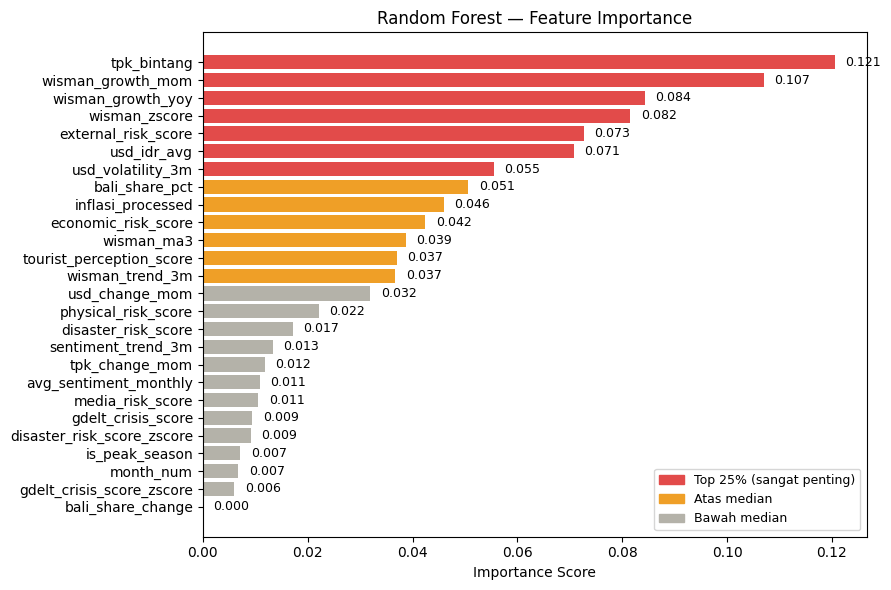

Top 5 fitur terpenting:
                feature  importance
6           tpk_bintang    0.120586
0     wisman_growth_mom    0.106979
1     wisman_growth_yoy    0.084259
2         wisman_zscore    0.081545
25  external_risk_score    0.072635


In [18]:
# Feature importance dari Random Forest
importances = rf_model.feature_importances_
fi_df = pd.DataFrame({
    'feature': FEATURES,
    'importance': importances
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#E24B4A' if v > fi_df['importance'].quantile(0.75) else
          '#EF9F27' if v > fi_df['importance'].median() else
          '#B4B2A9' for v in fi_df['importance']]

bars = ax.barh(fi_df['feature'], fi_df['importance'], color=colors)
ax.set_title('Random Forest — Feature Importance', fontsize=12)
ax.set_xlabel('Importance Score')

# Annotate
for bar, val in zip(bars, fi_df['importance']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

legend_patches = [
    mpatches.Patch(color='#E24B4A', label='Top 25% (sangat penting)'),
    mpatches.Patch(color='#EF9F27', label='Atas median'),
    mpatches.Patch(color='#B4B2A9', label='Bawah median'),
]
ax.legend(handles=legend_patches, fontsize=9)
plt.tight_layout()
plt.savefig('../data/final/feature_importance_rf.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 fitur terpenting:')
print(fi_df.tail(5)[['feature','importance']].sort_values('importance', ascending=False).to_string())

## 7. SHAP — Explainability

**SHAP (SHapley Additive exPlanations)** menjelaskan *mengapa* model membuat prediksi tertentu.
Untuk setiap prediksi, SHAP menunjukkan kontribusi positif/negatif dari setiap fitur.

Shape SHAP values: (192, 26, 4)
Classes: [np.str_('AMAN'), np.str_('WASPADA'), np.str_('SIAGA'), np.str_('KRISIS')]
SHAP array shape: (192, 26, 4)
Shape SHAP untuk KRISIS: (192, 26)
Shape X_scaled: (192, 26)



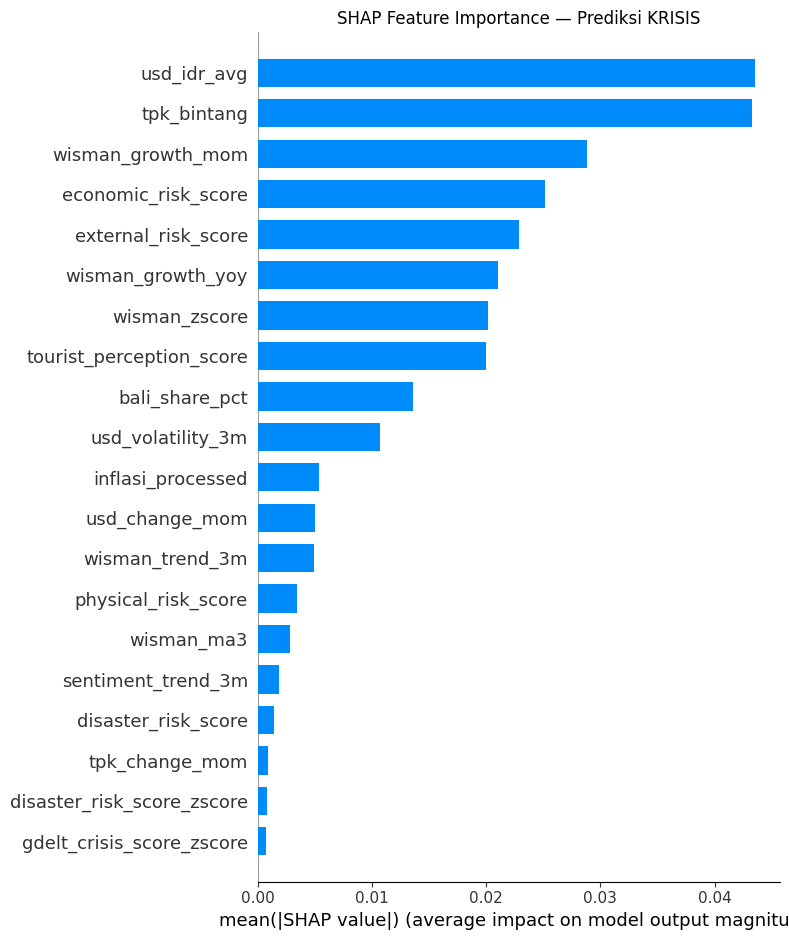

SHAP summary plot disimpan


In [19]:
try:
    import shap

    explainer = shap.TreeExplainer(rf_model)
    shap_values = explainer.shap_values(X_scaled)

    print('Shape SHAP values:', np.array(shap_values).shape)
    print('Classes:', list(le.classes_))

    # Format lama: list of arrays [n_classes][n_samples, n_features]
    # Format baru: single array [n_samples, n_features, n_classes]
    shap_arr = np.array(shap_values)
    print('SHAP array shape:', shap_arr.shape)

    krisis_idx = list(le.classes_).index('KRISIS')

    if shap_arr.ndim == 3:
        # Format baru: (n_samples, n_features, n_classes)
        shap_krisis = shap_arr[:, :, krisis_idx]
    else:
        # Format lama: (n_classes, n_samples, n_features)
        shap_krisis = shap_arr[krisis_idx]

    print('Shape SHAP untuk KRISIS:', shap_krisis.shape)
    print('Shape X_scaled:', X_scaled.shape)
    print()

    # Plot
    fig, ax = plt.subplots(figsize=(10, 7))
    shap.summary_plot(
        shap_krisis,
        X_scaled,
        feature_names=FEATURES,
        plot_type='bar',
        show=False
    )
    plt.title('SHAP Feature Importance — Prediksi KRISIS', fontsize=12)
    plt.tight_layout()
    plt.savefig('../data/final/shap_summary_krisis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('SHAP summary plot disimpan')

except ImportError:
    print('SHAP tidak tersedia. Install dengan: pip install shap')

### 7.1 SHAP Beeswarm Plot — Detail Kontribusi Fitur

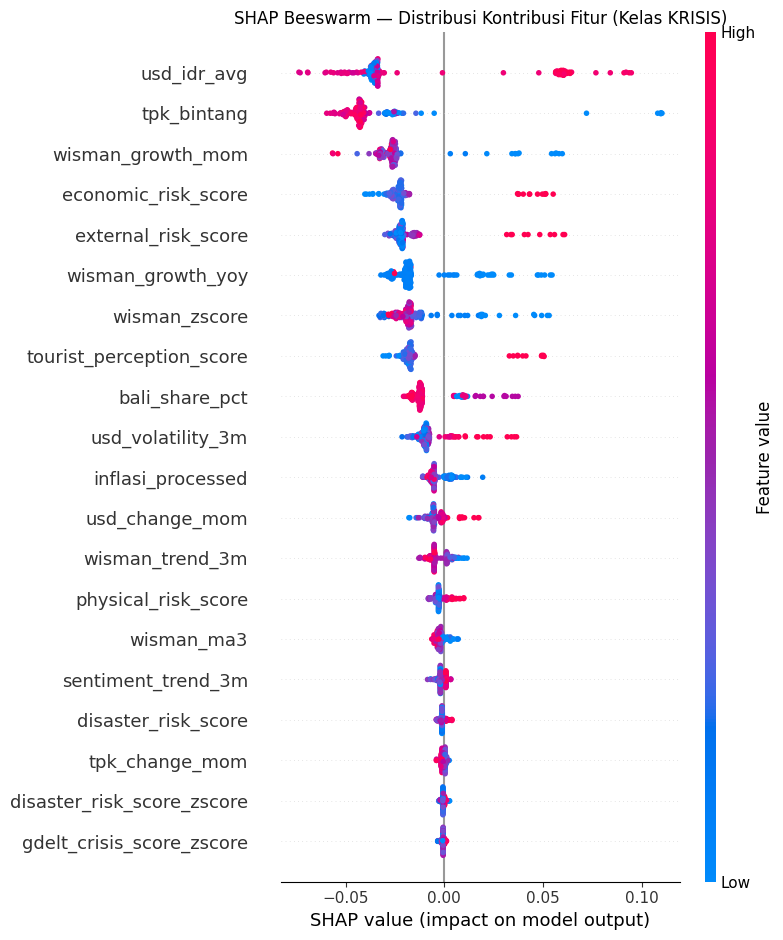

SHAP beeswarm disimpan

=== SHAP ANALISIS: Maret 2020 (puncak krisis) ===
                       feature  shap_value  feature_value
3                  usd_idr_avg      0.0911         1.0690
0            wisman_growth_mom      0.0581        -0.7066
18         economic_risk_score      0.0514         3.2726
24    tourist_perception_score      0.0503         3.2726
2                wisman_zscore      0.0494        -2.4382
1            wisman_growth_yoy      0.0472        -0.1491
25         external_risk_score      0.0425         2.9455
4            usd_volatility_3m      0.0367         4.6628
9               bali_share_pct      0.0345        -0.9532
5               usd_change_mom      0.0151         2.8636
14             wisman_trend_3m      0.0116        -3.6480
22         physical_risk_score      0.0099         1.7697
8            inflasi_processed      0.0062        -0.6405
19         disaster_risk_score      0.0039         1.7697
16          sentiment_trend_3m      0.0033         0.285

In [20]:
try:
    import shap

    # FIX: Pakai shap_krisis yang sudah difix di cell sebelumnya
    fig, ax = plt.subplots(figsize=(10, 7))
    shap.summary_plot(
        shap_krisis,        # ganti dari shap_krisis
        X_scaled,
        feature_names=FEATURES,
        plot_type='dot',
        show=False
    )
    plt.title('SHAP Beeswarm — Distribusi Kontribusi Fitur (Kelas KRISIS)', fontsize=12)
    plt.tight_layout()
    plt.savefig('../data/final/shap_beeswarm_krisis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('SHAP beeswarm disimpan')

    # Analisis bulan Mar 2020
    mar2020_idx = df_model[df_model['month'] == '2020-03'].index
    if len(mar2020_idx) > 0:
        idx_in_model = df_model.index.get_loc(mar2020_idx[0])
        print()
        print('=== SHAP ANALISIS: Maret 2020 (puncak krisis) ===')
        # FIX: pakai shap_krisis bukan shap_krisis
        krisis_shap_row = shap_krisis[idx_in_model]
        shap_explain = pd.DataFrame({
            'feature': FEATURES,
            'shap_value': krisis_shap_row,
            'feature_value': X_scaled[idx_in_model]
        }).sort_values('shap_value', ascending=False)
        print(shap_explain.round(4).to_string())

except ImportError:
    print('Skip SHAP beeswarm — SHAP tidak terinstall')

## 8. Gabungkan Semua Prediksi

In [21]:
# Gabungkan semua prediksi ke satu dataframe
df_model['rf_predicted_level'] = y_pred_labels
df_model['rf_correct'] = (df_model['rf_predicted_level'] == df_model[TARGET])

# Hitung confidence (max probability dari RF)
y_proba = rf_model.predict_proba(X_scaled)
df_model['rf_confidence'] = y_proba.max(axis=1)

# Mapping probabilitas per kelas
for i, cls in enumerate(le.classes_):
    df_model[f'prob_{cls.lower()}'] = y_proba[:, i]

print('=== RINGKASAN PREDIKSI ===')
print(f'Accuracy keseluruhan: {accuracy_score(y, y_pred)*100:.1f}%')
print()
print('Prediksi per periode kritis:')
kritis_periods = df_model[df_model[TARGET].isin(['SIAGA','KRISIS'])]
print(kritis_periods[['month','crisis_score_100',TARGET,'rf_predicted_level','rf_confidence']].to_string())

=== RINGKASAN PREDIKSI ===
Accuracy keseluruhan: 99.5%

Prediksi per periode kritis:
       month  crisis_score_100 crisis_level rf_predicted_level  rf_confidence
34   2011-11         46.588150        SIAGA              SIAGA       0.486412
74   2015-03         47.973500        SIAGA              SIAGA       0.522687
79   2015-08         47.750867        SIAGA              SIAGA       0.610333
82   2015-11         54.702678        SIAGA              SIAGA       0.658087
106  2017-11         48.445325        SIAGA              SIAGA       0.647922
133  2020-02         59.513970        SIAGA              SIAGA       0.617793
134  2020-03         75.327390       KRISIS             KRISIS       0.736587
135  2020-04         77.013790       KRISIS             KRISIS       0.902565
136  2020-05         67.336559       KRISIS             KRISIS       0.870433
137  2020-06         52.871249        SIAGA              SIAGA       0.636685
138  2020-07         71.491934       KRISIS             K

## 9. Simpan Model & Output

In [22]:
os.makedirs('../data/final', exist_ok=True)
os.makedirs('../models', exist_ok=True)

# Simpan model
joblib.dump(iso_forest, '../models/model_isolation_forest.pkl')
joblib.dump(rf_model,   '../models/model_random_forest.pkl')
joblib.dump(scaler,     '../models/scaler.pkl')
joblib.dump(le,         '../models/label_encoder.pkl')

print('Model disimpan ke ../models/')

# DIPERBAIKI: output_cols yang robust — pakai kolom yang pasti ada di df_model
# Kolom wajib sesuai spesifikasi predictions_final.csv (20 kolom)
OUTPUT_COLS_REQUIRED = [
    'month',
    'wisman',
    'tpk_bintang',
    'inflasi_processed',
    'usd_idr_avg',
    'avg_sentiment_monthly',
    'bali_share_pct',
    'wisman_zscore',
    'wisman_growth_mom',
    'wisman_growth_yoy',
    'crisis_score_100',
    TARGET,
    'rf_predicted_level',
    'rf_confidence',
    'prob_aman',
    'prob_waspada',
    'prob_siaga',
    'prob_krisis',
    'iso_anomaly',
    'iso_score',
    # Tambahan kolom external — ikut tersimpan di CSV output
    'gdelt_crisis_score',
    'economic_risk_score',
    'disaster_risk_score',
    'external_risk_avg',
    'physical_risk_score',
    'media_risk_score',
    'tourist_perception_score',
    'external_risk_score'
]

# Pastikan semua kolom wajib ada — tanpa merge ganda yang bisa bikin _x/_y
missing_output_cols = [c for c in OUTPUT_COLS_REQUIRED if c not in df_model.columns]
if missing_output_cols:
    print(f'⚠ Kolom berikut tidak ada di df_model, akan diambil dari df master: {missing_output_cols}')
    for col in missing_output_cols:
        if col in df.columns:
            # Pastikan tidak ada duplikasi — drop dulu jika sudah ada versi _x/_y
            src = df[['month', col]].copy()
            src['month'] = src['month'].astype(str)
            df_model = df_model.merge(src, on='month', how='left', suffixes=('', '_dup'))
            # Hapus kolom duplikat jika ada
            dup_col = col + '_dup'
            if dup_col in df_model.columns:
                df_model.drop(columns=[dup_col], inplace=True)
        else:
            print(f'  ✗ {col} tidak ditemukan di master dataset — akan diisi NaN')
            df_model[col] = np.nan

# Filter hanya kolom yang benar-benar ada
output_cols = [c for c in OUTPUT_COLS_REQUIRED if c in df_model.columns]
missing_final = [c for c in OUTPUT_COLS_REQUIRED if c not in df_model.columns]
if missing_final:
    print(f'✗ Kolom tidak tersedia dan tidak bisa diisi: {missing_final}')

print(df_model[
    [
        'month',
        'physical_risk_score',
        'media_risk_score',
        'tourist_perception_score',
        'external_risk_score'
    ]
].tail())

print(df_model[
    [
        'physical_risk_score',
        'media_risk_score',
        'tourist_perception_score',
        'external_risk_score'
    ]
].isna().sum())

predictions_df = df_model[output_cols].copy()
predictions_df.to_csv('../data/final/predictions_final.csv', index=False)

print(f'\nPrediksi disimpan ke ../data/final/predictions_final.csv')
print(f'   Shape: {predictions_df.shape}')
print(f'   Kolom ({len(output_cols)}): {output_cols}')

# ── TAMBAHAN: update master_dataset_clean.parquet & crisis_dataset_final.csv ──
ext_risk_cols = ['month', 'physical_risk_score', 'media_risk_score',
                 'tourist_perception_score', 'external_risk_score']
ext_for_master = df_model[[c for c in ext_risk_cols if c in df_model.columns]].copy()

# Update master_dataset_clean.parquet
master_updated = pd.read_parquet('../data/final/master_dataset_clean.parquet')
master_updated['month'] = master_updated['month'].astype(str)
# Drop kolom lama jika sudah ada (hindari duplikat saat re-run)
for _c in ['physical_risk_score','media_risk_score','tourist_perception_score','external_risk_score']:
    if _c in master_updated.columns:
        master_updated.drop(columns=[_c], inplace=True)
master_updated = master_updated.merge(ext_for_master, on='month', how='left')
master_updated.to_parquet('../data/final/master_dataset_clean.parquet', index=False)
print("✅ master_dataset_clean.parquet updated dengan 4 kolom baru")

# Update crisis_dataset_final.csv
crisis_updated = pd.read_csv('../data/final/crisis_dataset_final.csv')
crisis_updated['month'] = crisis_updated['month'].astype(str)
for _c in ['physical_risk_score','media_risk_score','tourist_perception_score','external_risk_score']:
    if _c in crisis_updated.columns:
        crisis_updated.drop(columns=[_c], inplace=True)
crisis_updated = crisis_updated.merge(ext_for_master, on='month', how='left')
crisis_updated.to_csv('../data/final/crisis_dataset_final.csv', index=False)
print("✅ crisis_dataset_final.csv updated dengan 4 kolom baru")

Model disimpan ke ../models/
⚠ Kolom berikut tidak ada di df_model, akan diambil dari df master: ['external_risk_avg']
  ✗ external_risk_avg tidak ditemukan di master dataset — akan diisi NaN
       month  physical_risk_score  media_risk_score  tourist_perception_score  \
187  2024-08             0.120314          0.300366                  0.360437   
188  2024-09             0.118904          0.340122                  0.360437   
189  2024-10             0.124066          0.334252                  0.360437   
190  2024-11             0.148245          0.368269                  0.360437   
191  2024-12             0.200723          0.348355                  0.360437   

     external_risk_score  
187             0.350793  
188             0.370901  
189             0.381726  
190             0.400937  
191             0.397827  
physical_risk_score         0
media_risk_score            0
tourist_perception_score    0
external_risk_score         0
dtype: int64

Prediksi disimpan ke ../d

## 10. Visualisasi Akhir — Crisis Timeline dengan Prediksi

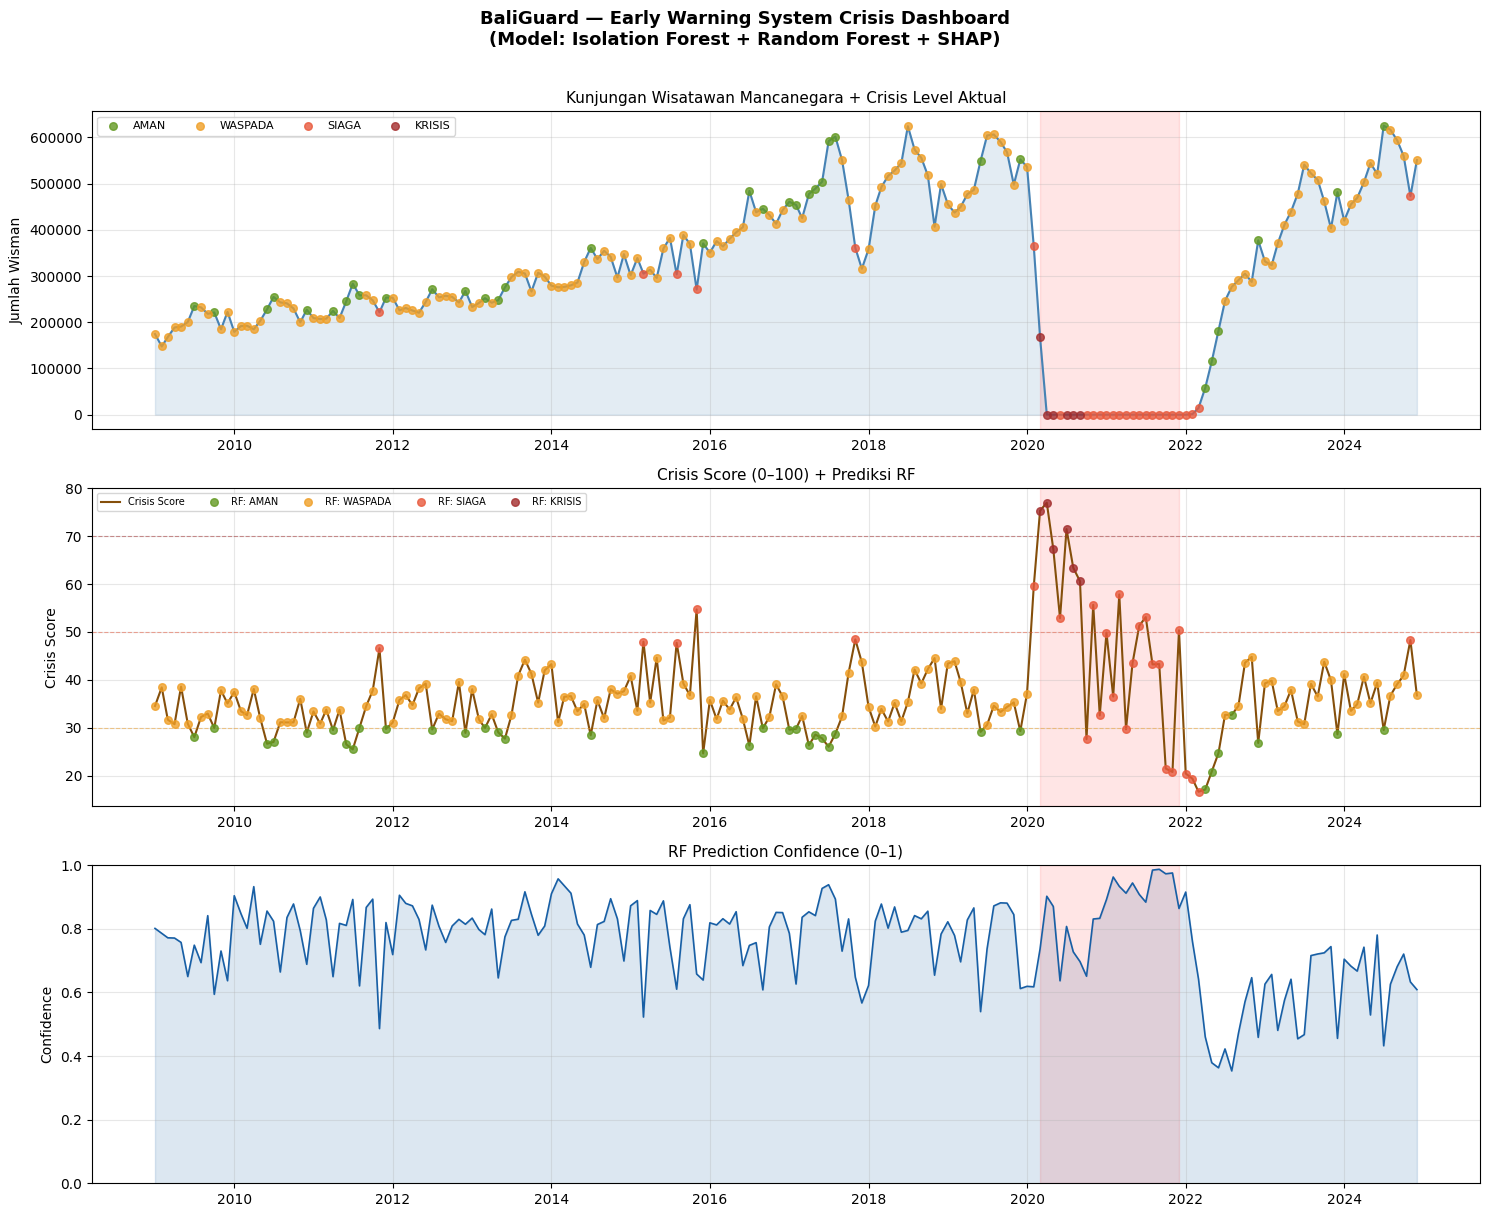

Plot final disimpan ke ../data/final/crisis_timeline_final.png


In [23]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12))
months_dt = pd.to_datetime(df_model['month'].astype(str))

color_map = {'AMAN': '#639922', 'WASPADA': '#EF9F27', 'SIAGA': '#E8593C', 'KRISIS': '#A32D2D'}

# Plot 1: Wisman dengan crisis level
ax1 = axes[0]
ax1.plot(months_dt, df_model['wisman'], color='steelblue', linewidth=1.5)
ax1.fill_between(months_dt, 0, df_model['wisman'], alpha=0.15, color='steelblue')
for level, color in color_map.items():
    mask = df_model[TARGET] == level
    ax1.scatter(months_dt[mask], df_model['wisman'][mask],
                color=color, s=30, zorder=5, label=level, alpha=0.8)
ax1.axvspan(pd.Timestamp('2020-03'), pd.Timestamp('2021-12'), alpha=0.1, color='red')
ax1.set_title('Kunjungan Wisatawan Mancanegara + Crisis Level Aktual', fontsize=11)
ax1.set_ylabel('Jumlah Wisman')
ax1.legend(fontsize=8, ncol=4)
ax1.grid(alpha=0.3)

# Plot 2: Crisis score + RF prediction
ax2 = axes[1]
ax2.plot(months_dt, df_model['crisis_score_100'], color='#854F0B', linewidth=1.5, label='Crisis Score')
for level, color in color_map.items():
    mask = df_model['rf_predicted_level'] == level
    ax2.scatter(months_dt[mask], df_model['crisis_score_100'][mask],
                color=color, s=30, zorder=5, alpha=0.8, label=f'RF: {level}')
ax2.axhline(70, color='#A32D2D', linestyle='--', alpha=0.5, linewidth=0.8)
ax2.axhline(50, color='#E8593C', linestyle='--', alpha=0.5, linewidth=0.8)
ax2.axhline(30, color='#EF9F27', linestyle='--', alpha=0.5, linewidth=0.8)
ax2.axvspan(pd.Timestamp('2020-03'), pd.Timestamp('2021-12'), alpha=0.1, color='red')
ax2.set_title('Crisis Score (0–100) + Prediksi RF', fontsize=11)
ax2.set_ylabel('Crisis Score')
ax2.legend(fontsize=7, ncol=5)
ax2.grid(alpha=0.3)

# Plot 3: RF confidence
ax3 = axes[2]
ax3.plot(months_dt, df_model['rf_confidence'], color='#185FA5', linewidth=1.2)
ax3.fill_between(months_dt, 0, df_model['rf_confidence'], alpha=0.15, color='#185FA5')
ax3.axvspan(pd.Timestamp('2020-03'), pd.Timestamp('2021-12'), alpha=0.1, color='red')
ax3.set_title('RF Prediction Confidence (0–1)', fontsize=11)
ax3.set_ylabel('Confidence')
ax3.set_ylim(0, 1)
ax3.grid(alpha=0.3)

plt.suptitle('BaliGuard — Early Warning System Crisis Dashboard\n(Model: Isolation Forest + Random Forest + SHAP)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/final/crisis_timeline_final.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot final disimpan ke ../data/final/crisis_timeline_final.png')

## 11. Ringkasan Model

In [24]:
print('=' * 55)
print('  BALIGUARD — RINGKASAN MODEL NB05')
print('=' * 55)
print()
print('Dataset:')
print(f'   {len(df_model)} baris × {len(FEATURES)} fitur')
print(f'   Periode: {df_model["month"].min()} → {df_model["month"].max()}')
print()
print('Isolation Forest:')
print(f'   Contamination: 15%')
print(f'   Anomali terdeteksi: {df_model["iso_anomaly"].sum()} bulan')
covid_detected = df_model[
    df_model['month'].between('2020-01','2021-12') &
    (df_model['iso_anomaly']==1)
]
print(f'   COVID months terdeteksi: {len(covid_detected)}/{len(df_model[df_model["month"].between("2020-01","2021-12")])}')
print()
print('Random Forest Classifier:')
acc = accuracy_score(y, y_pred) * 100
print(f'   Accuracy (training): {acc:.1f}%')
print(f'   CV Accuracy (walk-forward CV)       : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')
print(f'   CV F1 Macro  (walk-forward CV)       : {cv_f1.mean():.3f} ± {cv_f1.std():.3f}')
print(f'   n_estimators: 300, max_depth: 8')
print(f'   class_weight: balanced')
print()
print('Output tersimpan:')
print('   models/model_isolation_forest.pkl')
print('   models/model_random_forest.pkl')
print('   models/scaler.pkl')
print('   models/label_encoder.pkl')
print('   ../data/final/predictions_final.csv')
print()
print('Langkah selanjutnya: NB06 — LLM Narrative Engine + Dashboard Streamlit')
print('=' * 55)

  BALIGUARD — RINGKASAN MODEL NB05

Dataset:
   192 baris × 26 fitur
   Periode: 2009-01 → 2024-12

Isolation Forest:
   Contamination: 15%
   Anomali terdeteksi: 29 bulan
   COVID months terdeteksi: 16/24

Random Forest Classifier:
   Accuracy (training): 99.5%
   CV Accuracy (walk-forward CV)       : 0.566 ± 0.329
   CV F1 Macro  (walk-forward CV)       : 0.321 ± 0.193
   n_estimators: 300, max_depth: 8
   class_weight: balanced

Output tersimpan:
   models/model_isolation_forest.pkl
   models/model_random_forest.pkl
   models/scaler.pkl
   models/label_encoder.pkl
   ../data/final/predictions_final.csv

Langkah selanjutnya: NB06 — LLM Narrative Engine + Dashboard Streamlit


In [25]:
import pandas as pd

print("=== VERIFIKASI 4 KOLOM BARU ===")
targets = ['physical_risk_score','media_risk_score',
           'tourist_perception_score','external_risk_score']

# Cek predictions_final.csv
pred = pd.read_csv('../data/final/predictions_final.csv')
print(f"\npredictions_final.csv ({pred.shape}):")
for t in targets:
    val = pred[t].notna().sum() if t in pred.columns else 'TIDAK ADA'
    print(f"  {t}: {val}")

# Cek crisis_dataset_final.csv
crisis = pd.read_csv('../data/final/crisis_dataset_final.csv')
print(f"\ncrisis_dataset_final.csv ({crisis.shape}):")
for t in targets:
    val = crisis[t].notna().sum() if t in crisis.columns else 'TIDAK ADA'
    print(f"  {t}: {val}")

# Cek master_dataset_clean.parquet
master = pd.read_parquet('../data/final/master_dataset_clean.parquet')
print(f"\nmaster_dataset_clean.parquet ({master.shape}):")
for t in targets:
    val = master[t].notna().sum() if t in master.columns else 'TIDAK ADA'
    print(f"  {t}: {val}")

=== VERIFIKASI 4 KOLOM BARU ===

predictions_final.csv ((192, 28)):
  physical_risk_score: 192
  media_risk_score: 192
  tourist_perception_score: 192
  external_risk_score: 192

crisis_dataset_final.csv ((192, 49)):
  physical_risk_score: 192
  media_risk_score: 192
  tourist_perception_score: 192
  external_risk_score: 192

master_dataset_clean.parquet ((192, 49)):
  physical_risk_score: 192
  media_risk_score: 192
  tourist_perception_score: 192
  external_risk_score: 192
